In [1]:
# Импортируем необходимые библиотеки

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv
import os

In [3]:
# Загрузка переменных окружения

In [4]:
load_dotenv()
API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

print(DATE_BEGIN, DATE_END, API_URL)

2023-03-01 2023-09-01 https://data-charts-api.hexlet.app


In [5]:
# Создаем папку для графиков

In [6]:
charts_path = "./charts"
os.makedirs(charts_path, exist_ok=True)

In [7]:
# Получение данных и преобразование в датафрейм

In [8]:
def get_data(endpoint: str, start: str, end: str) -> pd.DataFrame:
    response = requests.get(f"{API_URL}/{endpoint}", params={"begin": start, "end": end})
    df = pd.DataFrame(response.json())
    return df

visits_raw = get_data("visits", DATE_BEGIN, DATE_END)
regs_raw = get_data("registrations", DATE_BEGIN, DATE_END)

In [9]:
# Отсекаем ботов

In [10]:
visits_clean = visits_raw[~visits_raw["user_agent"].str.contains("bot", case=False, na=False)].copy()

In [11]:
# Преобразуем datetime

In [12]:
visits_clean["datetime"] = pd.to_datetime(visits_clean["datetime"], utc=True, errors="coerce")
regs_raw["datetime"] = pd.to_datetime(regs_raw["datetime"], utc=True, errors="coerce")

In [13]:
# Берем последний визит для каждого visit_id

In [14]:
visits_last = visits_clean.sort_values("datetime").drop_duplicates(subset="visit_id", keep="last")
visits_last["date_group"] = visits_last["datetime"].dt.date
regs_raw["date_group"] = regs_raw["datetime"].dt.date

In [15]:
# Считаем визиты и регистрации по дате и платформе

In [16]:
visits_agg = visits_last.groupby(["date_group", "platform"]).size().reset_index(name="visits")
regs_agg = regs_raw.groupby(["date_group", "platform"]).size().reset_index(name="registrations")

In [17]:
# Расчет конверсии

In [18]:
conversion_df = pd.merge(visits_agg, regs_agg, on=["date_group", "platform"], how="left")
conversion_df["registrations"] = conversion_df["registrations"].fillna(0)
conversion_df["conversion"] = (conversion_df["registrations"] / conversion_df["visits"] * 100).round(2)

In [19]:
# Сохраняем json

In [20]:
conversion_df.to_json("./conversion.json")

In [21]:
# Добавляем рекламу

In [22]:
ads_raw = pd.read_csv("./ads.csv")
ads_raw["date"] = pd.to_datetime(ads_raw["date"])
ads_raw["date_group"] = ads_raw["date"].dt.date

ads_agg = ads_raw.groupby(["date_group", "utm_campaign"])["cost"].sum().reset_index()

In [23]:
# Объединяем с конверсией

In [24]:
ads_metrics = pd.merge(conversion_df, ads_agg, left_on="date_group", right_on="date_group", how="left")
ads_metrics["cost"] = ads_metrics["cost"].fillna(0)
ads_metrics["utm_campaign"] = ads_metrics["utm_campaign"].fillna("none")

ads_metrics = ads_metrics.sort_values(["date_group", "platform"]).reset_index(drop=True)
ads_metrics.to_json("./ads.json")

In [25]:
# Визиты по всем платформам

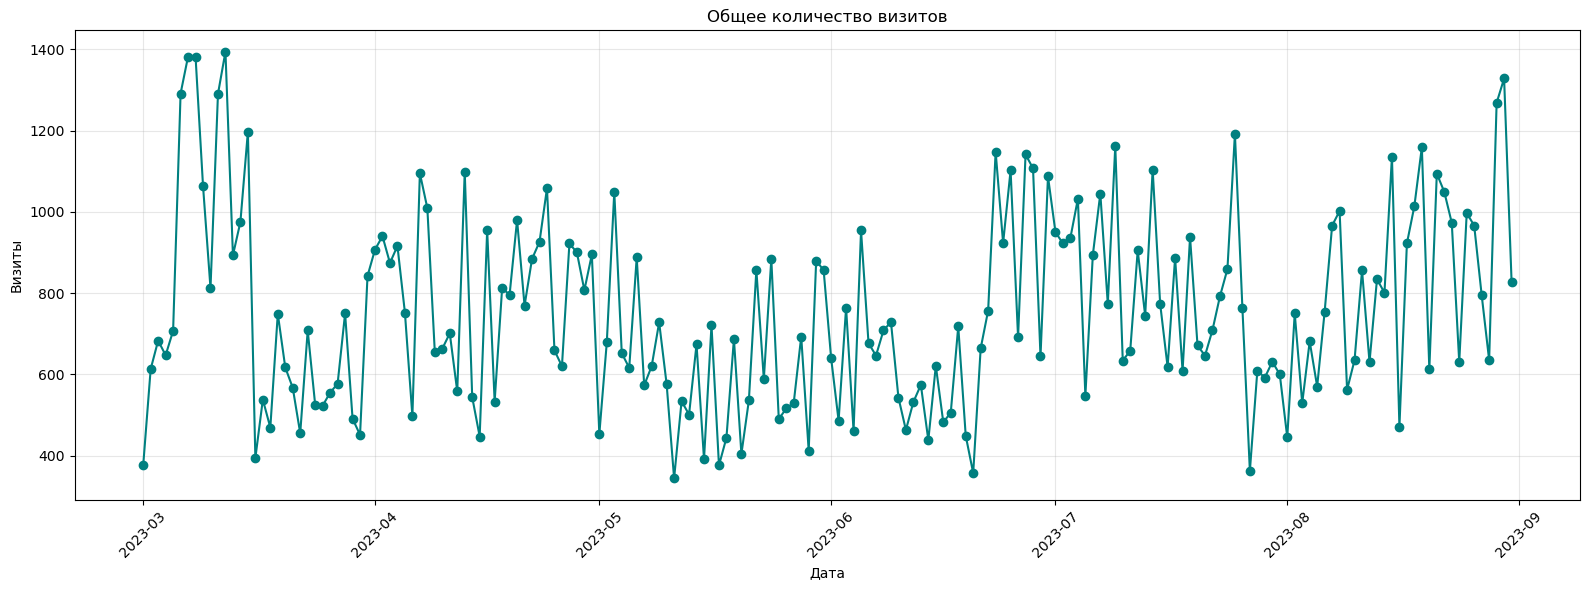

In [26]:
visits_daily = ads_metrics.groupby("date_group")["visits"].sum().reset_index()
plt.figure(figsize=(16,6))
plt.plot(visits_daily["date_group"], visits_daily["visits"], marker="o", color="teal")
plt.title("Общее количество визитов")
plt.xlabel("Дата")
plt.ylabel("Визиты")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/total_visits.png")
plt.show()

In [27]:
# Визиты по платформам

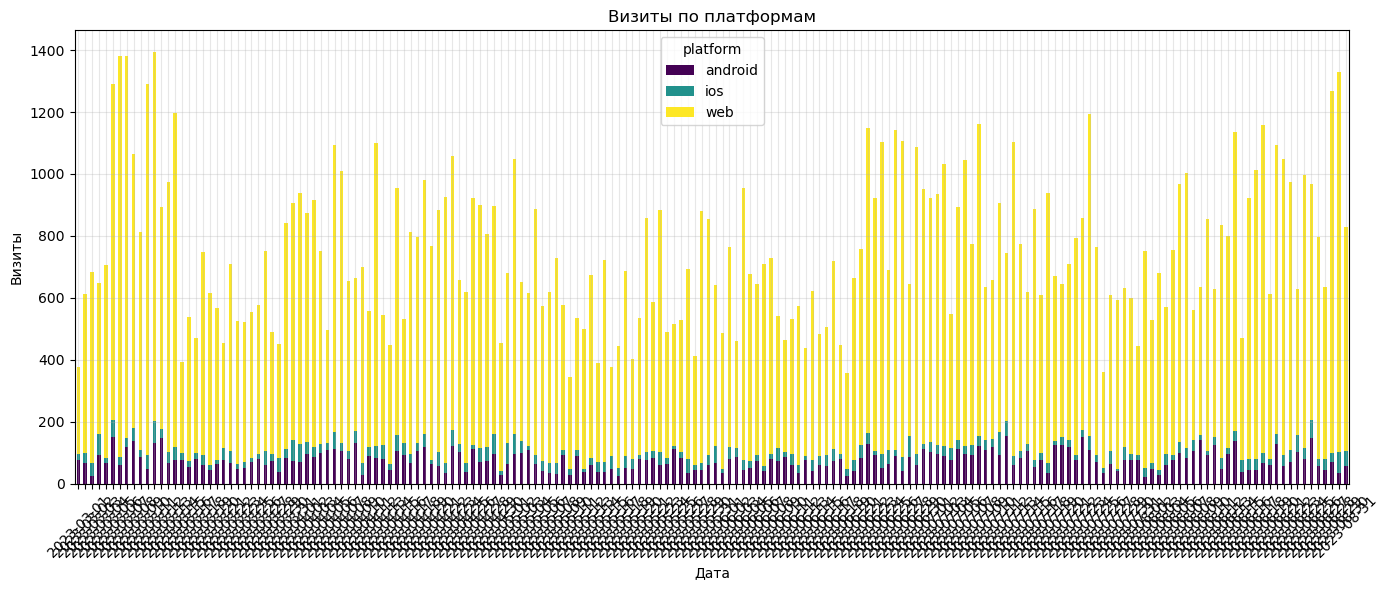

In [28]:
visits_platform = conversion_df.pivot(index="date_group", columns="platform", values="visits").fillna(0)
visits_platform.plot(kind="bar", stacked=True, figsize=(14,6), colormap="viridis")
plt.title("Визиты по платформам")
plt.xlabel("Дата")
plt.ylabel("Визиты")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{charts_path}/visits_by_platform.png")
plt.show()

In [29]:
# Регистрации по всем платформам

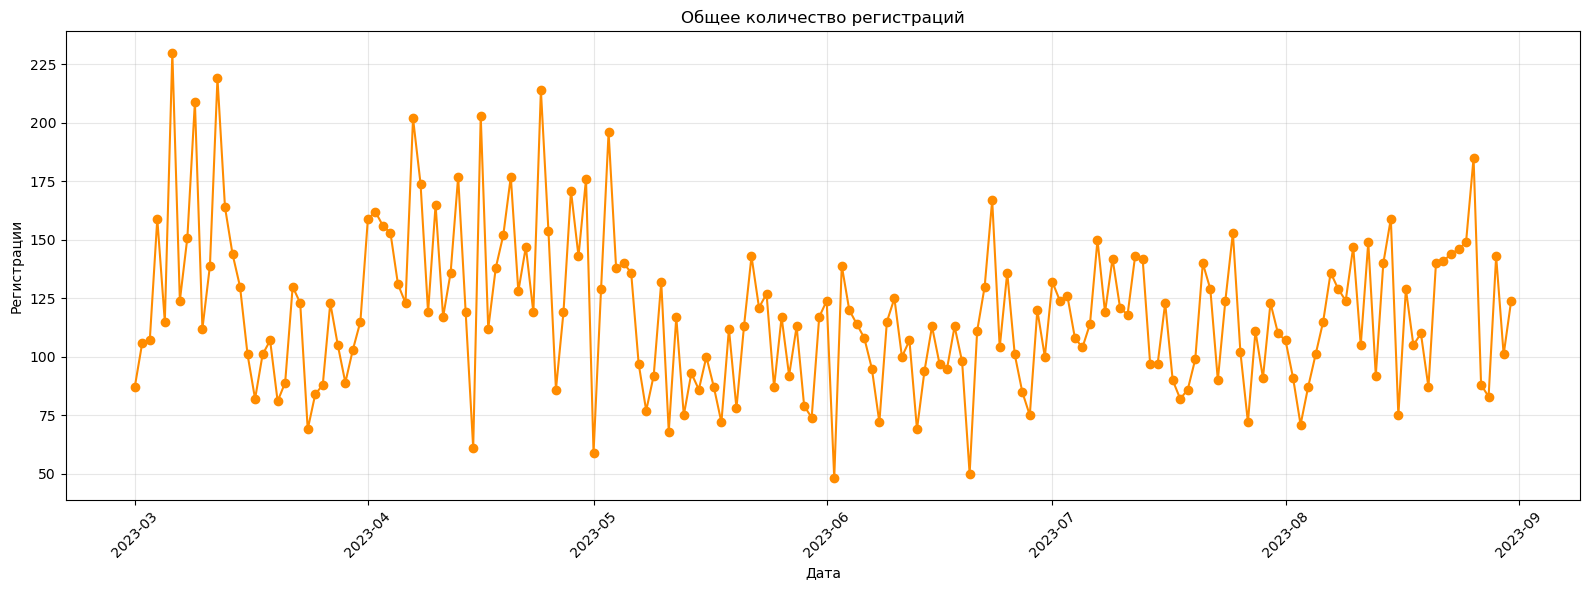

In [30]:
regs_daily = ads_metrics.groupby("date_group")["registrations"].sum().reset_index()
plt.figure(figsize=(16,6))
plt.plot(regs_daily["date_group"], regs_daily["registrations"], marker="o", color="darkorange")
plt.title("Общее количество регистраций")
plt.xlabel("Дата")
plt.ylabel("Регистрации")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/total_regs.png")
plt.show()

In [31]:
# Регистрации по платформам

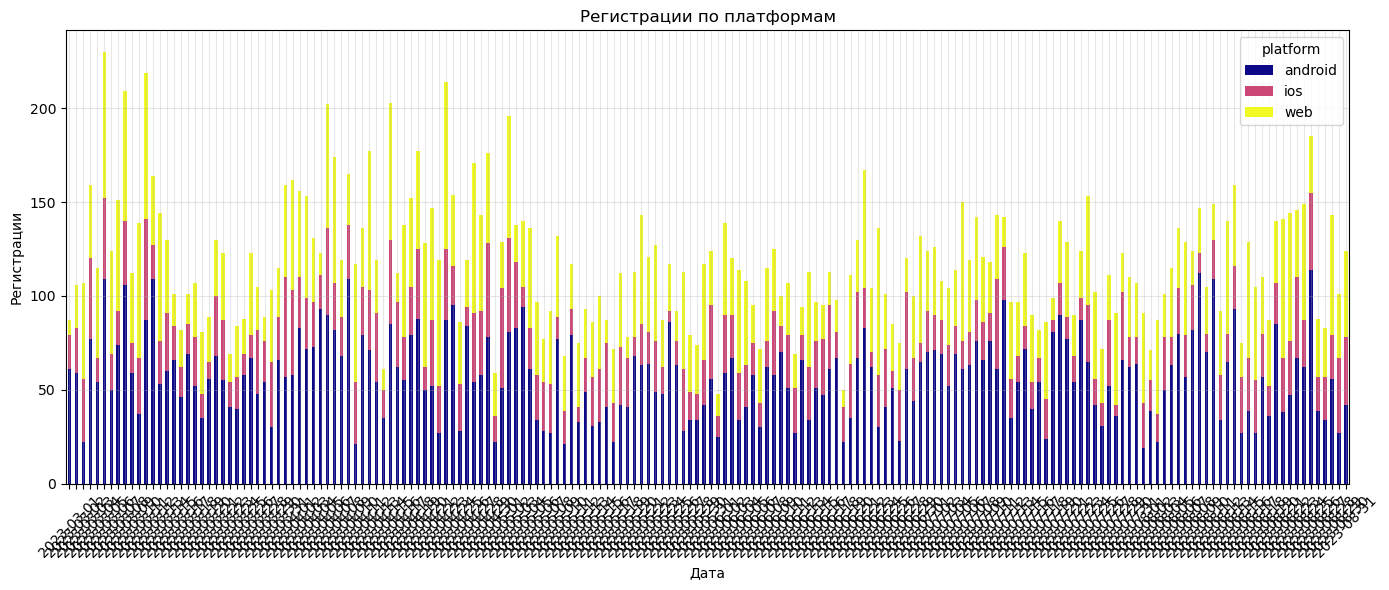

In [32]:
regs_platform = conversion_df.pivot(index="date_group", columns="platform", values="registrations").fillna(0)
regs_platform.plot(kind="bar", stacked=True, figsize=(14,6), colormap="plasma")
plt.title("Регистрации по платформам")
plt.xlabel("Дата")
plt.ylabel("Регистрации")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{charts_path}/regs_by_platform.png")
plt.show()

In [33]:
# Конверсия по платформам

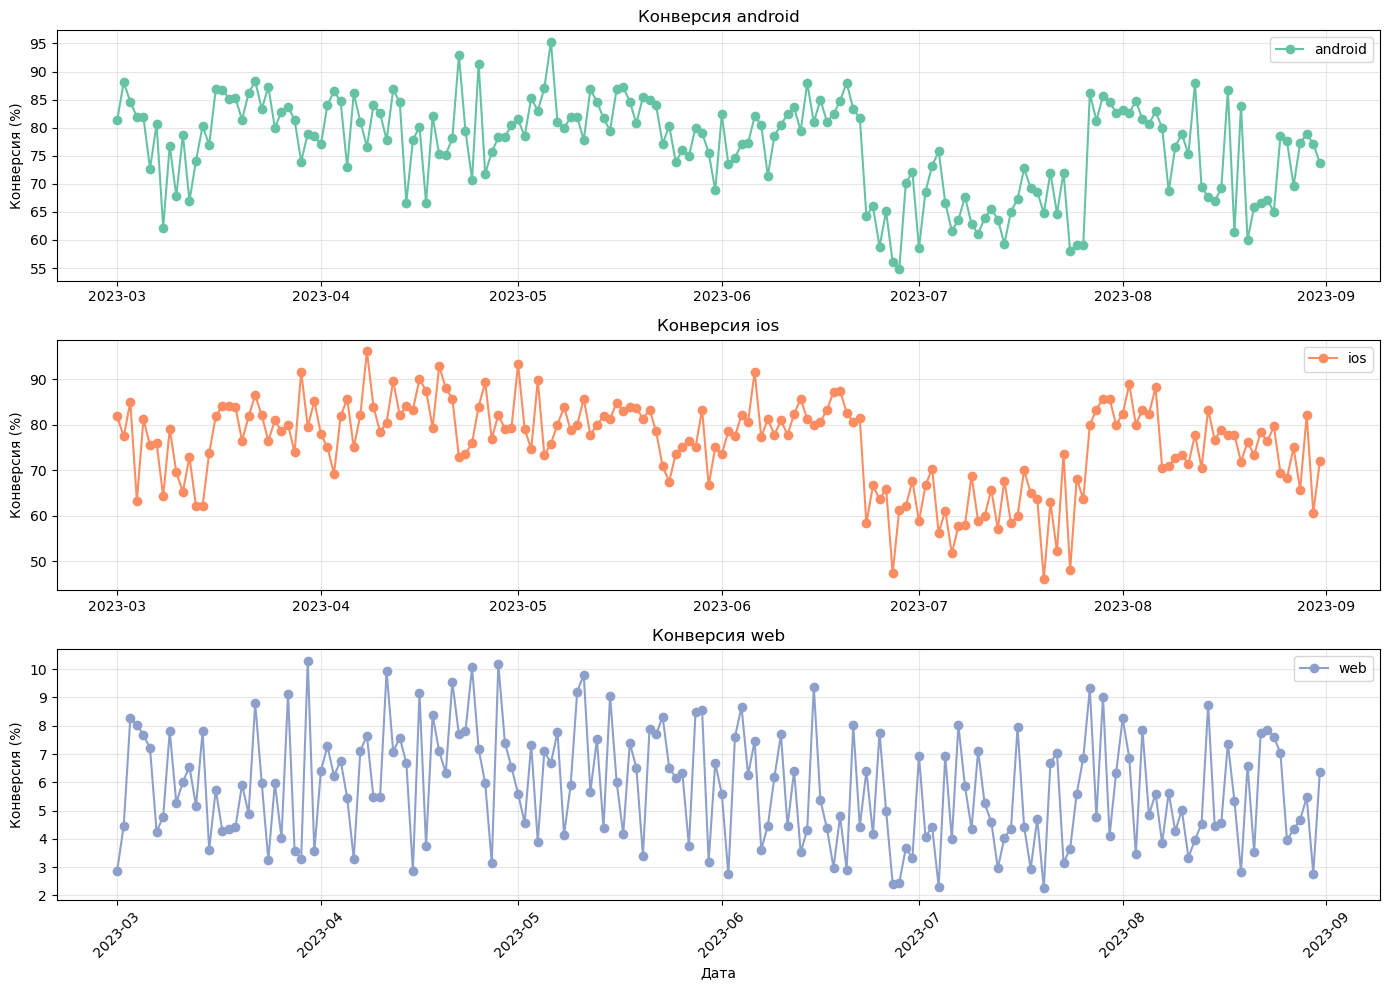

In [34]:
conv_platform = conversion_df.pivot(index="date_group", columns="platform", values="conversion").fillna(0)
plt.figure(figsize=(14,10))
for i, platform in enumerate(conv_platform.columns):
    plt.subplot(len(conv_platform.columns),1,i+1)
    plt.plot(conv_platform.index, conv_platform[platform], marker="o", label=platform, color=sns.color_palette("Set2")[i])
    plt.title(f"Конверсия {platform}")
    plt.ylabel("Конверсия (%)")
    plt.grid(alpha=0.3)
    plt.legend()
plt.xlabel("Дата")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/conversion_by_platform.png")
plt.show()

In [35]:
# Стоимость рекламы

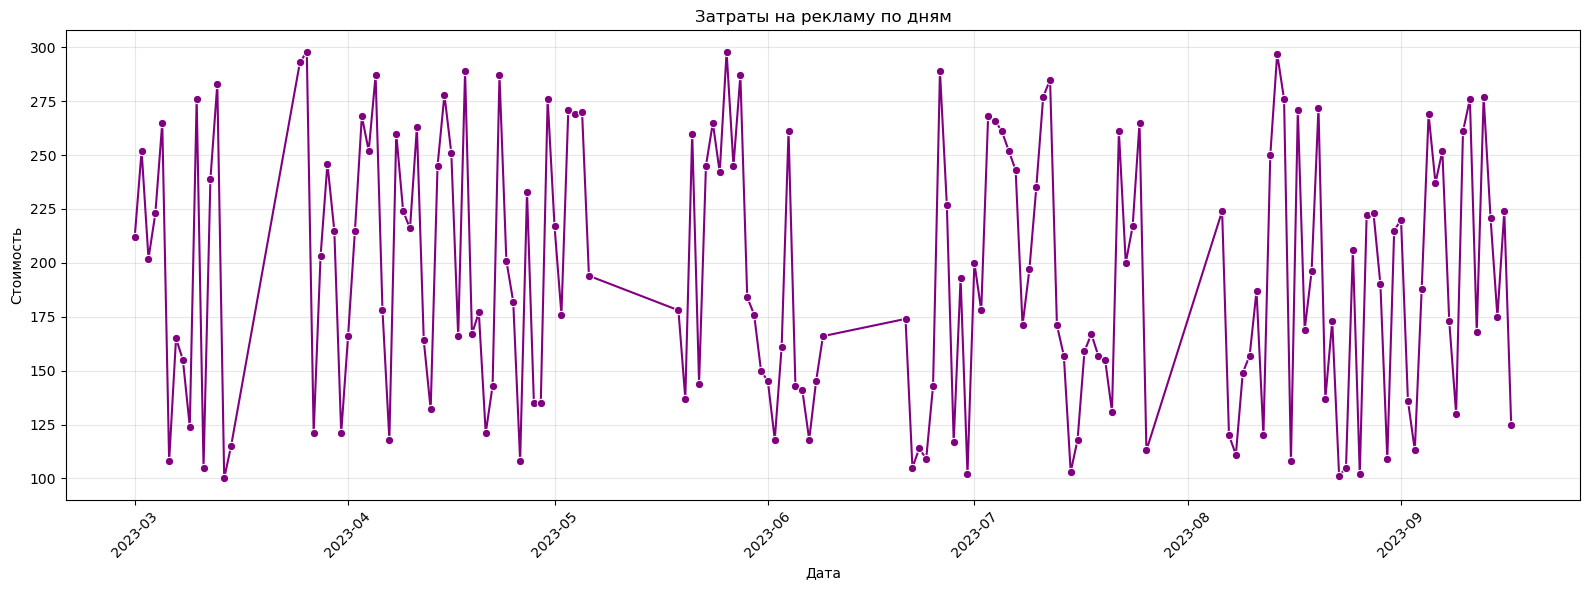

In [36]:
ads_costs = ads_raw.groupby("date_group")["cost"].sum().reset_index()
plt.figure(figsize=(16,6))
sns.lineplot(data=ads_costs, x="date_group", y="cost", marker="o", color="purple")
plt.title("Затраты на рекламу по дням")
plt.xlabel("Дата")
plt.ylabel("Стоимость")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/ads_costs.png")
plt.show()

In [37]:
# Визиты и регистрация с рекламой 

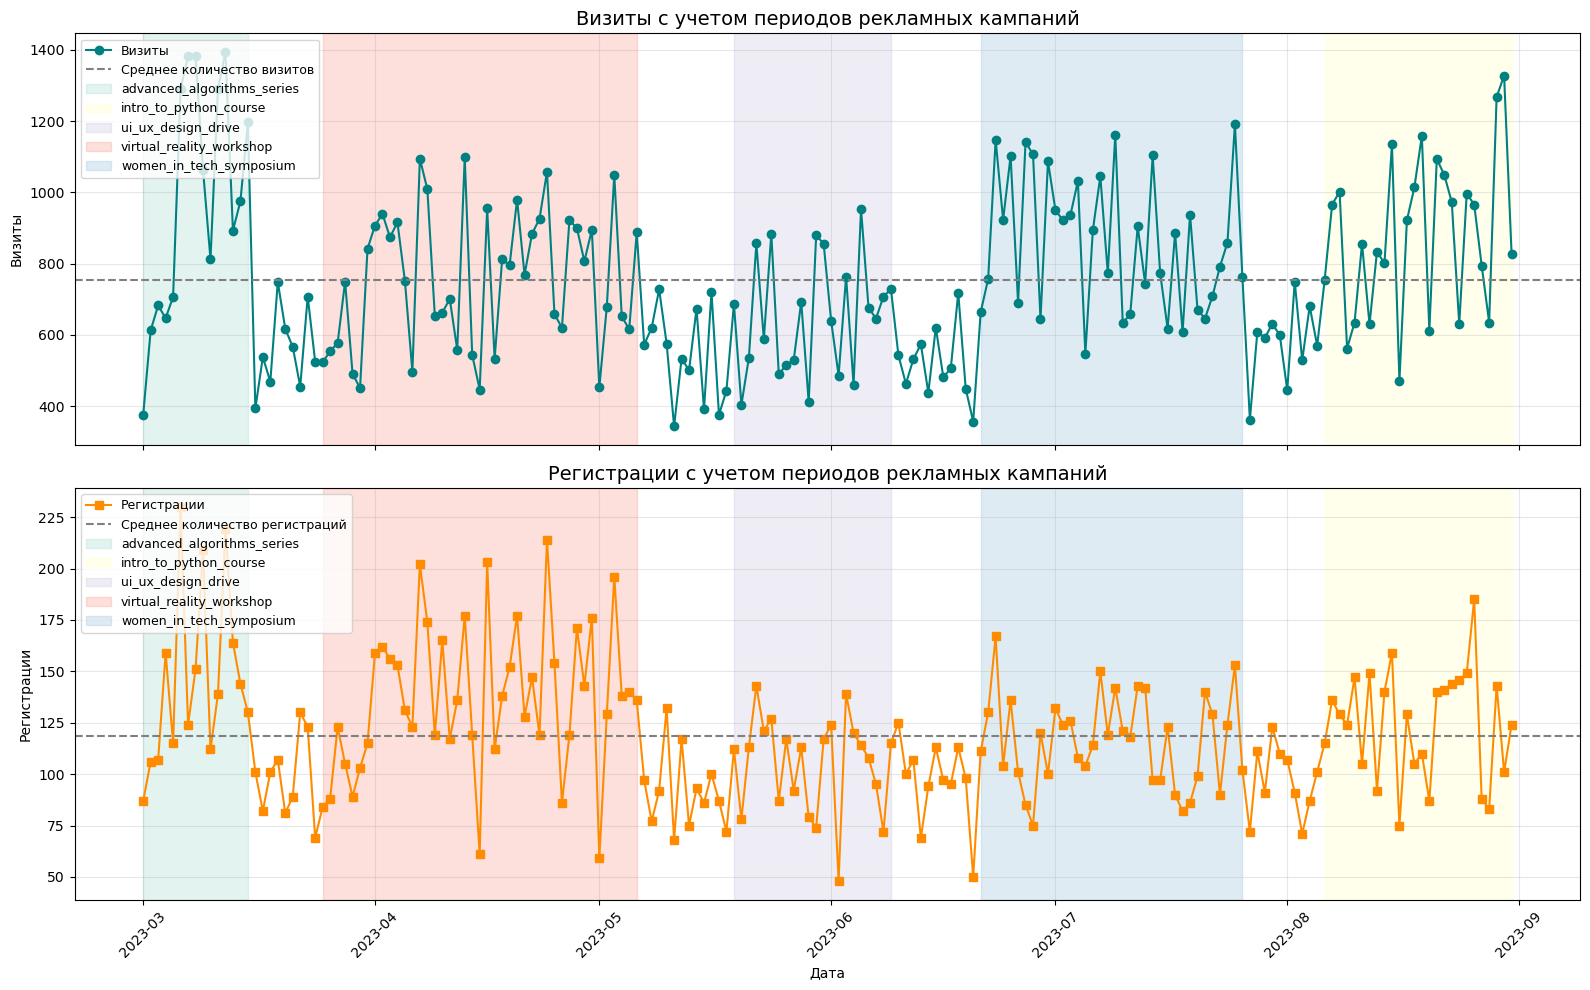

In [38]:
visits_daily = ads_metrics.groupby("date_group")["visits"].sum().reset_index()
regs_daily = ads_metrics.groupby("date_group")["registrations"].sum().reset_index()

ads_by_day = ads_metrics.groupby(["date_group", "utm_campaign"])["cost"].sum().reset_index()
ads_by_day = ads_by_day[ads_by_day["utm_campaign"] != "none"]

fig, ax = plt.subplots(2, 1, figsize=(16,10), sharex=True)

ax[0].plot(visits_daily["date_group"], visits_daily["visits"], marker="o", linestyle="-", color="teal", label="Визиты")
ax[0].axhline(visits_daily["visits"].mean(), color="gray", linestyle="--", label="Среднее количество визитов")

colors = plt.cm.Set3.colors
for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["date_group"].min()
    end = group["date_group"].max()
    ax[0].axvspan(start, end, alpha=0.25, color=colors[i % len(colors)], label=campaign)

ax[0].set_title("Визиты с учетом периодов рекламных кампаний", fontsize=14)
ax[0].set_ylabel("Визиты")
ax[0].legend(loc="upper left", fontsize=9)
ax[0].grid(alpha=0.3)

ax[1].plot(regs_daily["date_group"], regs_daily["registrations"], marker="s", linestyle="-", color="darkorange", label="Регистрации")
ax[1].axhline(regs_daily["registrations"].mean(), color="gray", linestyle="--", label="Среднее количество регистраций")

for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["date_group"].min()
    end = group["date_group"].max()
    ax[1].axvspan(start, end, alpha=0.25, color=colors[i % len(colors)], label=campaign)

ax[1].set_title("Регистрации с учетом периодов рекламных кампаний", fontsize=14)
ax[1].set_ylabel("Регистрации")
ax[1].set_xlabel("Дата")
ax[1].legend(loc="upper left", fontsize=9)
ax[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/visits_regs_with_ads.png")
plt.show()